# FinCast — Dataset Analysis
Produces charts, tables, and CSVs for human review and LLM/agent consumption.

In [14]:
import os, json, yaml, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13

DATA_DIR     = 'data/raw'
CONFIG_PATH  = 'gdelt_config.yaml'
ANALYSIS_DIR = 'analysis'
os.makedirs(ANALYSIS_DIR, exist_ok=True)

def save_csv(df, name):
    path = os.path.join(ANALYSIS_DIR, name)
    df.to_csv(path)
    print(f'  Saved: {path}')

print('Libraries loaded')

Libraries loaded


In [15]:
with open(CONFIG_PATH, 'r') as fh:
    cfg = yaml.safe_load(fh)
t = cfg.get('tickers', {})
ALL_TICKERS = {}
ALL_TICKERS.update({k: v for k, v in (t.get('company_queries', {}) or {}).items() if v})
ALL_TICKERS.update({k: v for k, v in (t.get('plain_names',    {}) or {}).items() if v})
ALL_TICKERS.update({k: v for k, v in (t.get('sector_queries', {}) or {}).items() if v})
BENCHMARKS      = t.get('benchmarks', {})
COMPANY_QUERIES = set((t.get('company_queries', {}) or {}).keys()) | \
                  set((t.get('plain_names',    {}) or {}).keys())
ETF_LABELS = {
    'SOXX':'Semiconductor','SKYY':'Cloud','DRIV':'EV','XLV':'Healthcare',
    'XLF':'Finance','BOTZ':'AI/Robotics','USO':'Oil','TLT':'Bonds',
    'UUP':'Dollar','XLK':'Tech ETF','CIBR':'Cybersec','SPY':'S&P500','QQQ':'Nasdaq'
}
print(f'Loaded {len(ALL_TICKERS)} ticker mappings')

Loaded 36 ticker mappings


In [16]:
def load_articles(data_dir):
    rows = []
    for root, _, files in os.walk(data_dir):
        for f in files:
            if not f.endswith('.json'): continue
            with open(os.path.join(root, f), 'r', encoding='utf-8') as fh:
                meta = json.load(fh)
            gdelt_query = meta.get('gdelt_query', '')
            ticker      = ALL_TICKERS.get(gdelt_query)
            if not ticker: continue
            pc           = meta.get('price_changes', {})
            ticker_pc    = pc.get(gdelt_query, {})
            benchmark    = BENCHMARKS.get(ticker, 'SPY')
            benchmark_pc = pc.get(benchmark, {})
            date_str     = (meta.get('publish_date') or meta.get('scrape_date',''))[:10]
            rows.append({
                'date':            pd.to_datetime(date_str, errors='coerce'),
                'site':            meta.get('site',''),
                'gdelt_query':     gdelt_query,
                'ticker':          ticker,
                'benchmark':       benchmark,
                'category':        'company' if gdelt_query in COMPANY_QUERIES else 'sector/macro',
                'title':           meta.get('title',''),
                'summary':         meta.get('summary',''),
                'sentiment':       meta.get('sentiment'),
                'word_count':      meta.get('word_count', 0),
                'base_price':      ticker_pc.get('base_price'),
                'next_price':      ticker_pc.get('next_price'),
                'change_1d':       ticker_pc.get('change_1d'),
                'bucket_1d':       ticker_pc.get('bucket_1d'),
                'magnitude':       ticker_pc.get('magnitude'),
                'bm_change_1d':    benchmark_pc.get('change_1d'),
                'bm_bucket_1d':    benchmark_pc.get('bucket_1d'),
                'url':             meta.get('url',''),
            })
    return pd.DataFrame(rows)

df = load_articles(DATA_DIR).sort_values('date').reset_index(drop=True)
print(f'Loaded {len(df):,} articles')
print(f'Date range:      {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Unique tickers:  {df["ticker"].nunique()}')
print(f'With price data: {df["bucket_1d"].notna().sum():,}')

Loaded 2,128 articles
Date range:      2026-03-14 to 2026-03-28
Unique tickers:  19
With price data: 1,393


## 1 — Article & Ticker Distribution

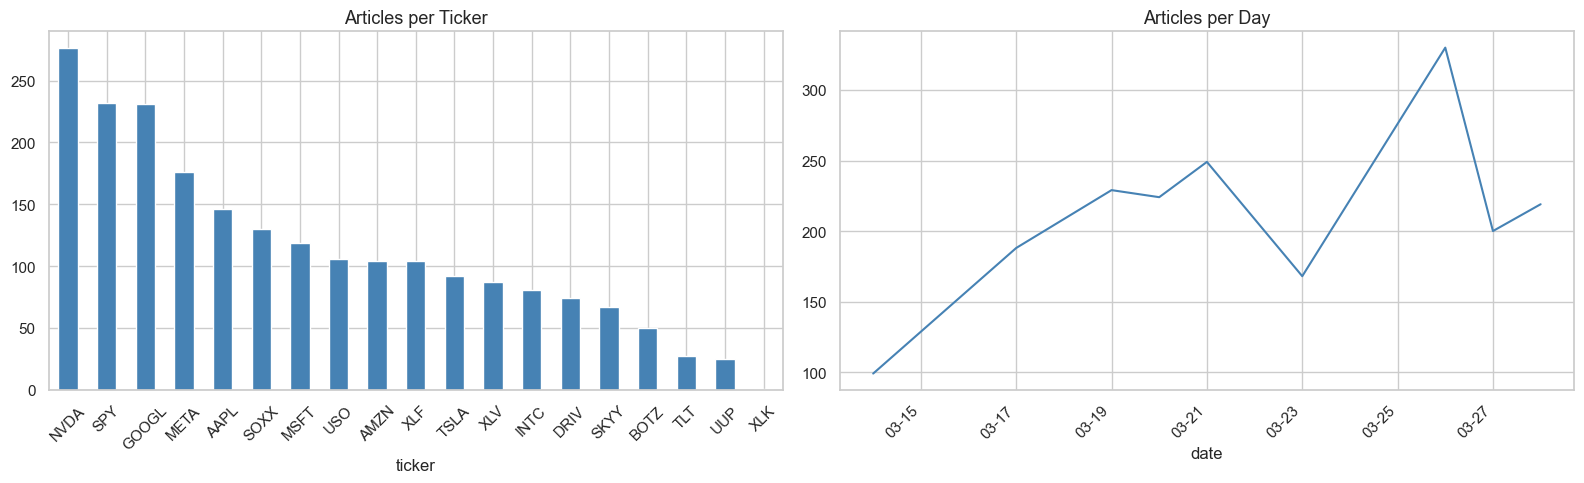

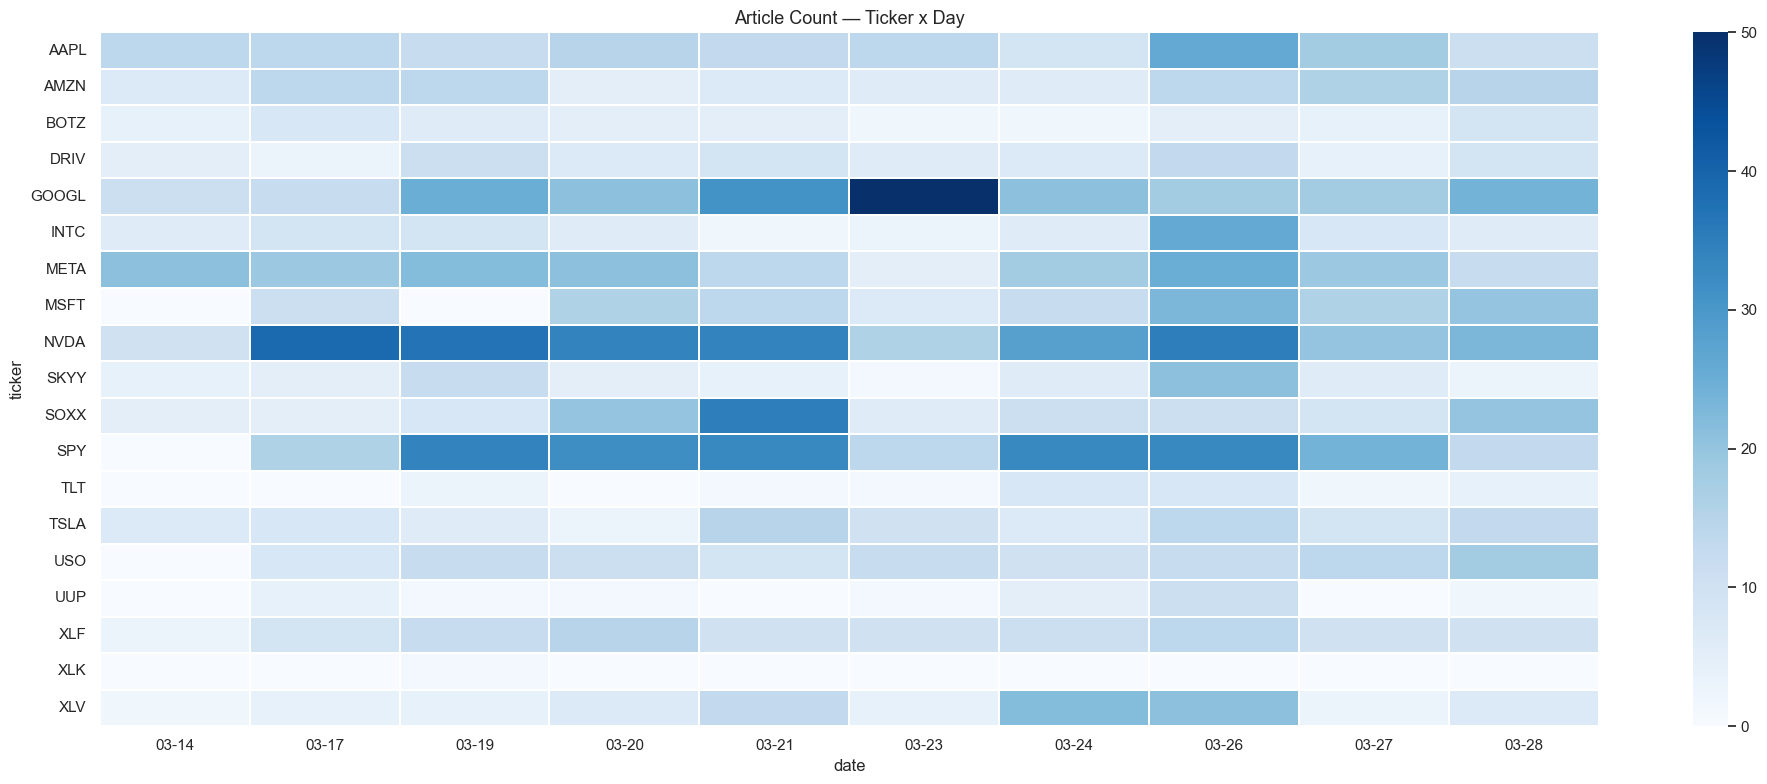


--- Articles per Ticker ---


,count,pct
ticker,,
NVDA,276,13.0
SPY,232,10.9
GOOGL,231,10.9
META,176,8.3
AAPL,146,6.9
SOXX,130,6.1
MSFT,119,5.6
USO,106,5.0
AMZN,104,4.9


  Saved: analysis\dist_articles_per_ticker.csv

--- Articles per Day ---


,count
date,
2026-03-14,99
2026-03-17,188
2026-03-19,229
2026-03-20,224
2026-03-21,249
2026-03-23,168
2026-03-24,222
2026-03-26,330
2026-03-27,200


  Saved: analysis\dist_articles_per_day.csv
  Saved: analysis\dist_ticker_day_heatmap.csv


In [17]:
# Charts
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ticker_counts = df['ticker'].value_counts()
ticker_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Articles per Ticker')
axes[0].tick_params(axis='x', rotation=45)
daily = df.groupby('date').size()
daily.plot(ax=axes[1], color='steelblue', linewidth=1.5)
axes[1].set_title('Articles per Day')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout(); plt.show()

pivot = df.pivot_table(index='ticker', columns=df['date'].dt.strftime('%m-%d'),
                       values='url', aggfunc='count', fill_value=0)
plt.figure(figsize=(20, 8))
sns.heatmap(pivot, cmap='Blues', linewidths=0.3)
plt.title('Article Count — Ticker x Day')
plt.tight_layout(); plt.show()

# Tables
ticker_table = ticker_counts.rename('count').to_frame()
ticker_table['pct'] = (ticker_table['count'] / len(df) * 100).round(1)
print('\n--- Articles per Ticker ---')
display(ticker_table)
save_csv(ticker_table, 'dist_articles_per_ticker.csv')

daily_table = daily.rename('count').to_frame()
daily_table.index = daily_table.index.strftime('%Y-%m-%d')
print('\n--- Articles per Day ---')
display(daily_table)
save_csv(daily_table, 'dist_articles_per_day.csv')
save_csv(pivot, 'dist_ticker_day_heatmap.csv')

## 2 — Sentiment Distribution

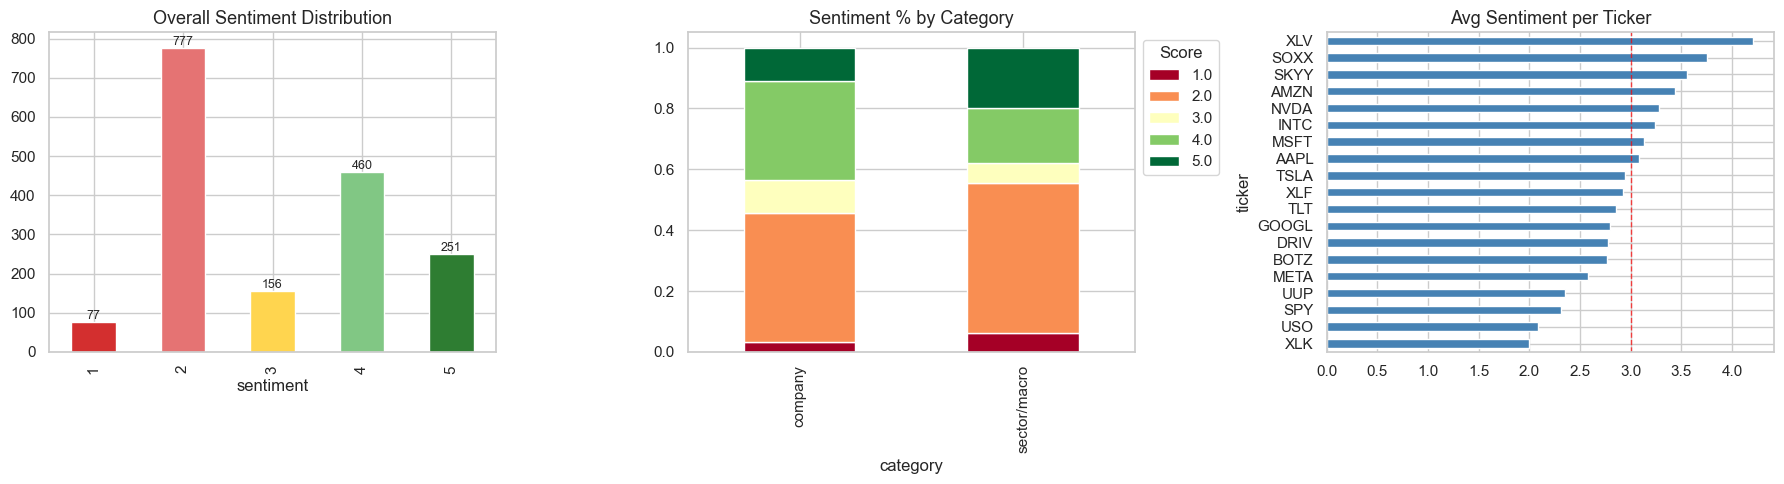


--- Sentiment Distribution ---


,count,pct
sentiment_score,,
1,77,4.5
2,777,45.1
3,156,9.1
4,460,26.7
5,251,14.6


  Saved: analysis\dist_sentiment.csv

--- Sentiment Stats per Ticker ---


,count,mean,std,min,max
ticker,,,,,
AAPL,130,3.08,1.03,1.0,5.0
AMZN,97,3.43,1.21,1.0,5.0
BOTZ,43,2.77,1.19,1.0,5.0
DRIV,45,2.78,1.02,2.0,5.0
GOOGL,128,2.80,1.00,1.0,5.0
INTC,75,3.24,1.09,1.0,5.0
META,160,2.58,1.14,1.0,5.0
MSFT,96,3.14,1.14,1.0,5.0
NVDA,252,3.28,1.19,1.0,5.0


  Saved: analysis\dist_sentiment_per_ticker.csv


In [18]:
colors = ['#d32f2f','#e57373','#ffd54f','#81c784','#2e7d32']
sent   = df['sentiment'].dropna().astype(int).value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sent.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Overall Sentiment Distribution')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)
df.dropna(subset=['sentiment']).groupby('category')['sentiment'] \
  .value_counts(normalize=True).unstack() \
  .plot(kind='bar', ax=axes[1], colormap='RdYlGn', stacked=True)
axes[1].set_title('Sentiment % by Category')
axes[1].legend(title='Score', bbox_to_anchor=(1,1))
df.groupby('ticker')['sentiment'].mean().sort_values() \
  .plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].axvline(3, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[2].set_title('Avg Sentiment per Ticker')
plt.tight_layout(); plt.show()

# Tables
sent_table = pd.DataFrame({'count': sent, 'pct': (sent/sent.sum()*100).round(1)})
sent_table.index.name = 'sentiment_score'
print('\n--- Sentiment Distribution ---')
display(sent_table)
save_csv(sent_table, 'dist_sentiment.csv')

sent_ticker = df.dropna(subset=['sentiment']).groupby('ticker')['sentiment'].agg(
    count='count', mean='mean', std='std', min='min', max='max').round(2)
print('\n--- Sentiment Stats per Ticker ---')
display(sent_ticker)
save_csv(sent_ticker, 'dist_sentiment_per_ticker.csv')

flat_pct = sent.get(3,0)/sent.sum()*100
if flat_pct > 50:
    print(f'\n⚠ Neutral sentiment (3) = {flat_pct:.1f}% — consider more targeted queries')

## 3 — Price Bucket Distribution

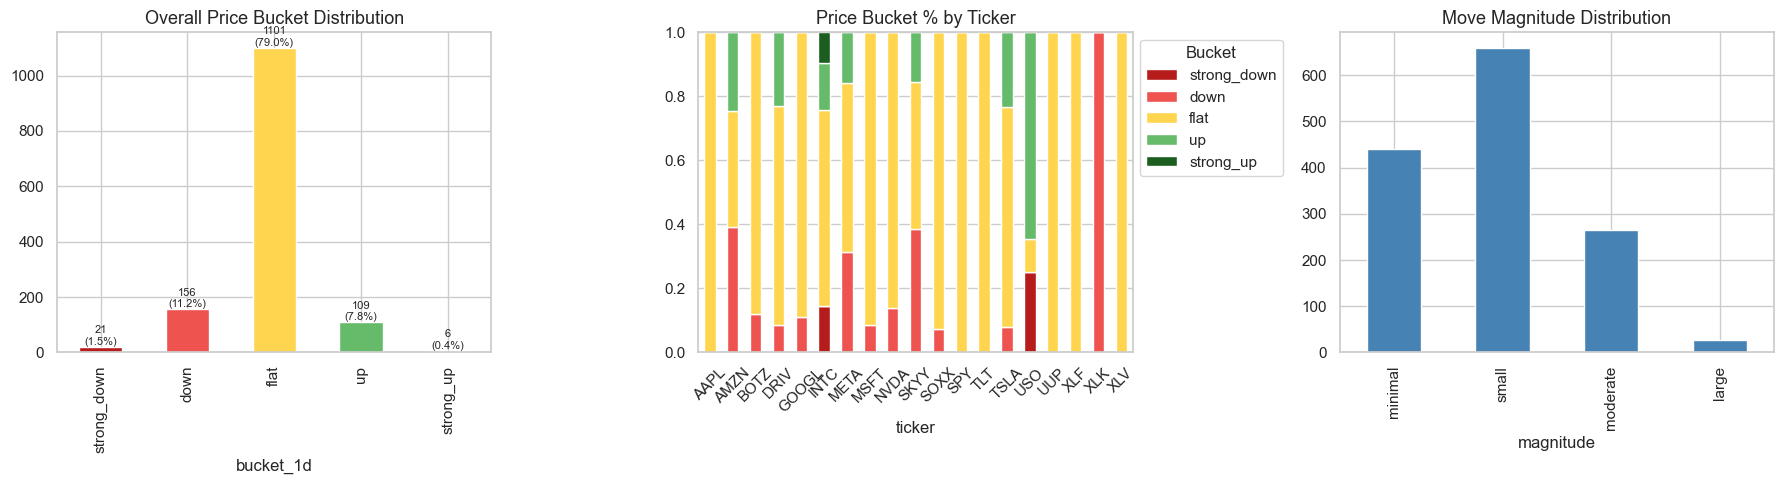


--- Price Bucket Distribution ---


,count,pct
bucket_1d,,
strong_down,21,1.5
down,156,11.2
flat,1101,79.0
up,109,7.8
strong_up,6,0.4


  Saved: analysis\dist_price_buckets.csv

--- Price Bucket % per Ticker ---


,strong_down_pct,down_pct,flat_pct,up_pct,strong_up_pct,flat_flag
ticker,,,,,,
AAPL,NaN,NaN,100.0,NaN,NaN,HIGH
AMZN,NaN,39.1,36.2,24.6,NaN,OK
BOTZ,NaN,12.1,87.9,NaN,NaN,HIGH
DRIV,NaN,8.6,68.6,22.9,NaN,OK
GOOGL,NaN,11.0,89.0,NaN,NaN,HIGH
INTC,14.5,NaN,61.3,14.5,9.7,OK
META,NaN,31.3,53.0,15.7,NaN,OK
MSFT,NaN,8.6,91.4,NaN,NaN,HIGH
NVDA,NaN,13.9,86.1,NaN,NaN,HIGH


  Saved: analysis\dist_price_buckets_per_ticker.csv

--- Magnitude Distribution ---


,count,pct
magnitude,,
minimal,441,31.7
small,660,47.4
moderate,265,19.0
large,27,1.9


  Saved: analysis\dist_magnitude.csv


In [19]:
labeled       = df.dropna(subset=['bucket_1d'])
bucket_order  = ['strong_down','down','flat','up','strong_up']
colors_bucket = ['#b71c1c','#ef5350','#ffd54f','#66bb6a','#1b5e20']
bucket_counts = labeled['bucket_1d'].value_counts().reindex(bucket_order, fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bucket_counts.plot(kind='bar', ax=axes[0], color=colors_bucket)
axes[0].set_title('Overall Price Bucket Distribution')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}\n({p.get_height()/len(labeled)*100:.1f}%)',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=8)
labeled.groupby('ticker')['bucket_1d'].value_counts(normalize=True).unstack() \
    .reindex(columns=bucket_order, fill_value=0) \
    .plot(kind='bar', stacked=True, ax=axes[1], color=colors_bucket)
axes[1].set_title('Price Bucket % by Ticker')
axes[1].legend(title='Bucket', bbox_to_anchor=(1,1))
axes[1].tick_params(axis='x', rotation=45)
mag_order = ['minimal','small','moderate','large']
labeled['magnitude'].value_counts().reindex(mag_order, fill_value=0) \
    .plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Move Magnitude Distribution')
plt.tight_layout(); plt.show()

# Tables
bucket_table = pd.DataFrame({
    'count': bucket_counts,
    'pct':   (bucket_counts/bucket_counts.sum()*100).round(1)
})
print('\n--- Price Bucket Distribution ---')
display(bucket_table)
save_csv(bucket_table, 'dist_price_buckets.csv')

bucket_ticker = labeled.groupby('ticker')['bucket_1d'] \
    .value_counts(normalize=True).unstack() \
    .reindex(columns=bucket_order, fill_value=0).mul(100).round(1)
bucket_ticker.columns = [f'{c}_pct' for c in bucket_ticker.columns]
bucket_ticker['flat_flag'] = bucket_ticker.get('flat_pct', pd.Series(dtype=float)).apply(
    lambda x: 'HIGH' if x > 70 else 'OK')
print('\n--- Price Bucket % per Ticker ---')
display(bucket_ticker)
save_csv(bucket_ticker, 'dist_price_buckets_per_ticker.csv')

mag_table = labeled['magnitude'].value_counts().reindex(mag_order, fill_value=0)
mag_df = pd.DataFrame({'count': mag_table, 'pct': (mag_table/mag_table.sum()*100).round(1)})
print('\n--- Magnitude Distribution ---')
display(mag_df)
save_csv(mag_df, 'dist_magnitude.csv')

## 4 — Sentiment vs Price Mismatch

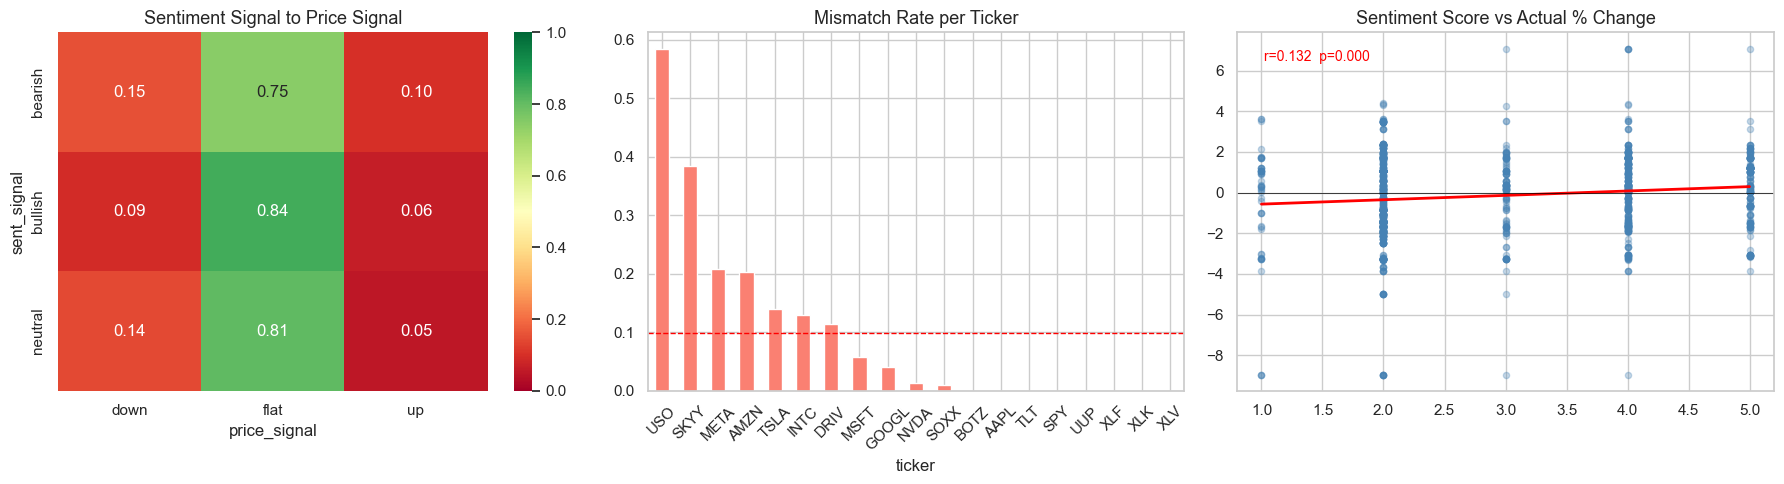


--- Confusion Matrix (counts) ---


price_signal,down,flat,up,Total
sent_signal,,,,
bearish,110,536,73,719
bullish,50,468,36,554
neutral,17,97,6,120
Total,177,1101,115,1393


  Saved: analysis\mismatch_confusion_matrix.csv

--- Mismatch Rate per Ticker ---


,mismatch_rate,mismatch_pct,flag
ticker,,,
USO,0.583333,58.3,HIGH
SKYY,0.384615,38.5,OK
META,0.208955,20.9,OK
AMZN,0.202899,20.3,OK
TSLA,0.140625,14.1,OK
INTC,0.129032,12.9,OK
DRIV,0.114286,11.4,OK
MSFT,0.057143,5.7,OK
GOOGL,0.040000,4.0,OK


  Saved: analysis\mismatch_rate_per_ticker.csv

Overall mismatch rate: 8.8%
Pearson r: 0.132  p=0.0000  significant


In [20]:
labeled = df.dropna(subset=['sentiment','bucket_1d']).copy()
labeled['sentiment']    = labeled['sentiment'].astype(int)
labeled['sent_signal']  = labeled['sentiment'].apply(
    lambda x: 'bullish' if x>=4 else ('bearish' if x<=2 else 'neutral'))
labeled['price_signal'] = labeled['bucket_1d'].apply(
    lambda x: 'up' if x in ('up','strong_up') else ('down' if x in ('down','strong_down') else 'flat'))
labeled['mismatch']     = (
    ((labeled['sent_signal']=='bullish') & (labeled['price_signal']=='down')) |
    ((labeled['sent_signal']=='bearish') & (labeled['price_signal']=='up'))
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm = pd.crosstab(labeled['sent_signal'], labeled['price_signal'], normalize='index')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[0], vmin=0, vmax=1)
axes[0].set_title('Sentiment Signal to Price Signal')
mismatch_rate = labeled.groupby('ticker')['mismatch'].mean().sort_values(ascending=False)
mismatch_rate.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].axhline(mismatch_rate.mean(), color='red', linestyle='--', linewidth=1)
axes[1].set_title('Mismatch Rate per Ticker')
axes[1].tick_params(axis='x', rotation=45)
sample = labeled.dropna(subset=['change_1d'])
axes[2].scatter(sample['sentiment'], sample['change_1d'], alpha=0.3, s=20, color='steelblue')
z = np.polyfit(sample['sentiment'], sample['change_1d'], 1)
xs = np.linspace(1, 5, 100)
axes[2].plot(xs, np.poly1d(z)(xs), color='red', linewidth=2)
axes[2].axhline(0, color='black', linewidth=0.5)
r, p_val = stats.pearsonr(sample['sentiment'], sample['change_1d'])
axes[2].annotate(f'r={r:.3f}  p={p_val:.3f}', xy=(0.05,0.92),
                 xycoords='axes fraction', fontsize=10,
                 color='red' if p_val<0.05 else 'grey')
axes[2].set_title('Sentiment Score vs Actual % Change')
plt.tight_layout(); plt.show()

# Tables
cm_counts = pd.crosstab(labeled['sent_signal'], labeled['price_signal'],
                        margins=True, margins_name='Total')
print('\n--- Confusion Matrix (counts) ---')
display(cm_counts)
save_csv(cm_counts, 'mismatch_confusion_matrix.csv')

mismatch_table = mismatch_rate.rename('mismatch_rate').to_frame()
mismatch_table['mismatch_pct'] = (mismatch_table['mismatch_rate']*100).round(1)
mismatch_table['flag'] = mismatch_table['mismatch_rate'].apply(
    lambda x: 'HIGH' if x>0.4 else 'OK')
print('\n--- Mismatch Rate per Ticker ---')
display(mismatch_table)
save_csv(mismatch_table, 'mismatch_rate_per_ticker.csv')

print(f'\nOverall mismatch rate: {labeled["mismatch"].mean()*100:.1f}%')
print(f'Pearson r: {r:.3f}  p={p_val:.4f}  {"significant" if p_val<0.05 else "not significant yet"}')

## 5 — Edge Cases

In [21]:
mismatches  = labeled[labeled['mismatch']].copy()
edge_cols   = ['date','ticker','sentiment','sent_signal','bucket_1d',
                'price_signal','change_1d','magnitude','summary','url']
edge_table  = mismatches[edge_cols].copy()
edge_table['date'] = edge_table['date'].dt.strftime('%Y-%m-%d')

print(f'Total mismatches: {len(edge_table)}')
print('\n--- Bullish Sentiment but Price Dropped (worst 10) ---')
display(edge_table[edge_table['sent_signal']=='bullish'].sort_values('change_1d').head(10))
print('\n--- Bearish Sentiment but Price Rose (top 10) ---')
display(edge_table[edge_table['sent_signal']=='bearish'].sort_values('change_1d', ascending=False).head(10))
save_csv(edge_table.set_index('url'), 'edge_cases.csv')

Total mismatches: 123

--- Bullish Sentiment but Price Dropped (worst 10) ---


,date,ticker,sentiment,sent_signal,bucket_1d,price_signal,change_1d,magnitude,summary,url
704,2026-03-20,USO,4,bullish,strong_down,down,-8.9517,large,Iran's missile attacks on Middle Eastern energ...,https://www.livemint.com/market/commodities/oi...
1106,2026-03-23,GOOGL,5,bullish,down,down,-3.8469,moderate,Google and American Airlines' AI-guided contra...,https://www.pymnts.com/artificial-intelligence...
1135,2026-03-23,GOOGL,4,bullish,down,down,-3.8469,moderate,The Rajasthan Board of Secondary Education is ...,https://www.livemint.com/education/rbse-result...
1033,2026-03-23,GOOGL,4,bullish,down,down,-3.8469,moderate,"Women fishers in Siargao, Philippines, are bot...",https://www.scmp.com/opinion/letters/article/3...
1084,2026-03-23,GOOGL,4,bullish,down,down,-3.8469,moderate,"Google is integrating its AI assistant, Gemini...",https://www.digitaltrends.com/phones/chrome-on...
1425,2026-03-26,META,4,bullish,down,down,-3.2984,moderate,Meta Platforms offers stock options to top exe...,https://www.businesstimes.com.sg/companies-mar...
460,2026-03-19,NVDA,4,bullish,down,down,-3.2818,moderate,Deutsche Bank analysts are optimistic about Ub...,https://www.businessinsider.com/uber-stock-sel...
428,2026-03-19,NVDA,4,bullish,down,down,-3.2818,moderate,Supermicro is among the first to introduce a n...,https://www.thehindubusinessline.com/brandhub/...
483,2026-03-19,NVDA,4,bullish,down,down,-3.2818,moderate,South Korean stocks surged over 5% due to a se...,https://www.upi.com/Top_News/World-News/2026/0...
1439,2026-03-26,META,4,bullish,down,down,-3.2217,moderate,Meta's C-suite executives are set to receive a...,https://www.businessinsider.com/meta-boost-exe...



--- Bearish Sentiment but Price Rose (top 10) ---


,date,ticker,sentiment,sent_signal,bucket_1d,price_signal,change_1d,magnitude,summary,url
1707,2026-03-26,USO,2,bearish,up,up,4.3834,moderate,Oil prices found support around its 20-day mov...,https://www.investing.com/analysis/oil-swings-...
1592,2026-03-26,USO,2,bearish,up,up,4.3408,moderate,Indian government bond yields rose marginally ...,https://www.livemint.com/market/bonds/indian-1...
1408,2026-03-26,USO,2,bearish,up,up,4.3152,moderate,The 2-year Treasury yield surged due to weak d...,https://www.cnbc.com/2026/03/24/treasury-yield...
1031,2026-03-23,USO,2,bearish,up,up,3.5999,moderate,The Philippines temporarily permits the use of...,https://www.scmp.com/news/asia/southeast-asia/...
1107,2026-03-23,USO,1,bearish,up,up,3.5999,moderate,U.S. and Iranian threats to target energy faci...,https://www.livemint.com/market/oil-prices-to-...
1102,2026-03-23,USO,1,bearish,up,up,3.5999,moderate,Ongoing conflict in Iran and the closure of th...,https://fortune.com/2026/03/22/gasoline-prices...
1072,2026-03-23,USO,2,bearish,up,up,3.5999,moderate,Ongoing conflict in West Asia and crude oil pr...,https://www.thehindubusinessline.com/markets/w...
950,2026-03-21,TSLA,2,bearish,up,up,3.5031,moderate,Jurors found Musk intentionally misled Twitter...,https://fortune.com/2026/03/20/musk-twitter-bu...
680,2026-03-20,TSLA,2,bearish,up,up,3.5031,moderate,The National Highway Traffic Safety Administra...,https://www.cnbc.com/2026/03/19/tesla-nhtsa-fu...
907,2026-03-21,TSLA,2,bearish,up,up,3.5031,moderate,Elon Musk was found liable for allegedly defra...,https://www.channelnewsasia.com/business/elon-...


  Saved: analysis\edge_cases.csv


## 6 — Stock vs Benchmark Correlation

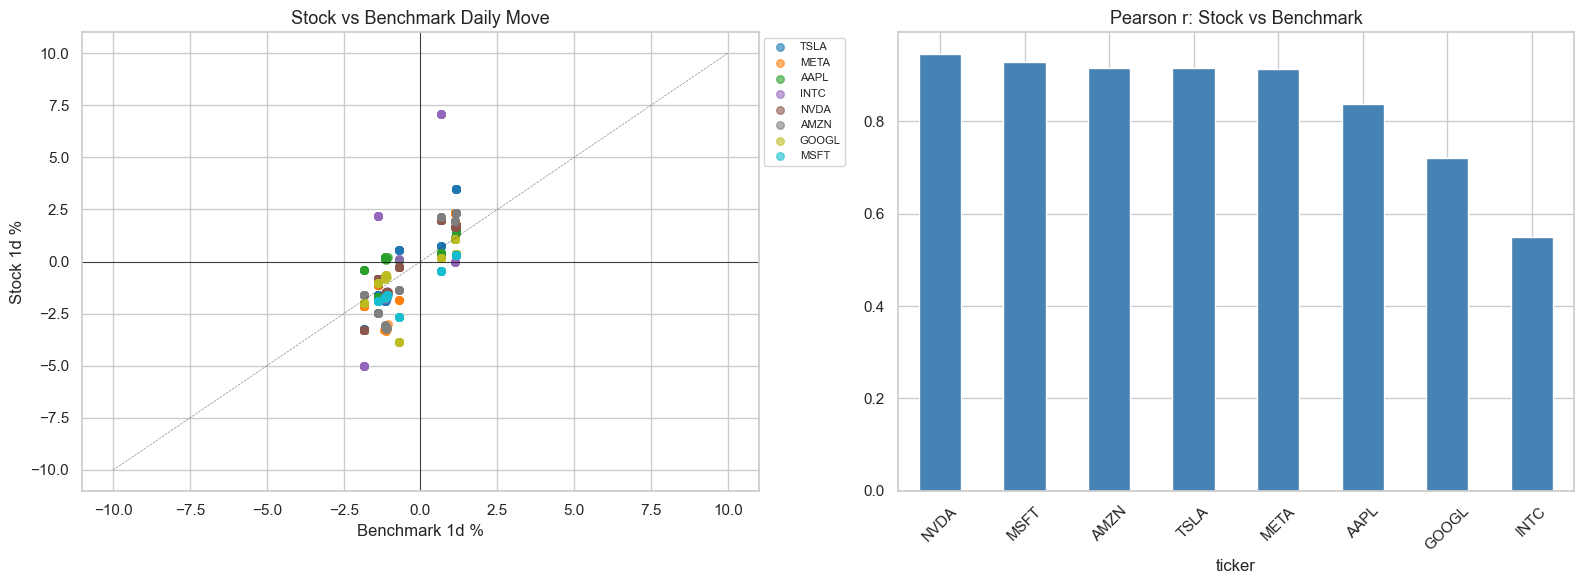


--- Stock vs Benchmark Correlation ---


,benchmark,r,p,n
ticker,,,,
NVDA,QQQ,0.945,0.0,216
MSFT,QQQ,0.928,0.0,70
AMZN,QQQ,0.916,0.0,69
TSLA,QQQ,0.915,0.0,64
META,QQQ,0.913,0.0,134
AAPL,QQQ,0.837,0.0,104
GOOGL,QQQ,0.721,0.0,100
INTC,QQQ,0.549,0.0,62


  Saved: analysis\correlations_stock_vs_benchmark.csv


In [22]:
company_df = df[df['category']=='company'].dropna(subset=['change_1d','bm_change_1d']).copy()
if company_df.empty:
    print('No data yet')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    tickers = company_df['ticker'].unique()
    colors  = plt.cm.tab10(np.linspace(0, 1, len(tickers)))
    for ticker, color in zip(tickers, colors):
        sub = company_df[company_df['ticker']==ticker]
        axes[0].scatter(sub['bm_change_1d'], sub['change_1d'],
                        label=ticker, alpha=0.6, s=30, color=color)
    axes[0].axhline(0, color='black', linewidth=0.5)
    axes[0].axvline(0, color='black', linewidth=0.5)
    axes[0].plot([-10,10],[-10,10],'k--',linewidth=0.5,alpha=0.5)
    axes[0].set_xlabel('Benchmark 1d %'); axes[0].set_ylabel('Stock 1d %')
    axes[0].set_title('Stock vs Benchmark Daily Move')
    axes[0].legend(bbox_to_anchor=(1,1), fontsize=8)
    corrs = []
    for ticker in tickers:
        sub = company_df[company_df['ticker']==ticker]
        if len(sub) > 5:
            r, p = stats.pearsonr(sub['bm_change_1d'], sub['change_1d'])
            corrs.append({'ticker': ticker, 'benchmark': sub['benchmark'].iloc[0],
                          'r': round(r,3), 'p': round(p,4), 'n': len(sub)})
    corr_df = pd.DataFrame(corrs).set_index('ticker').sort_values('r', ascending=False)
    corr_df['r'].plot(kind='bar', ax=axes[1], color='steelblue')
    axes[1].set_title('Pearson r: Stock vs Benchmark')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout(); plt.show()
    print('\n--- Stock vs Benchmark Correlation ---')
    display(corr_df)
    save_csv(corr_df, 'correlations_stock_vs_benchmark.csv')

## 7 — Macro Impact on Stocks

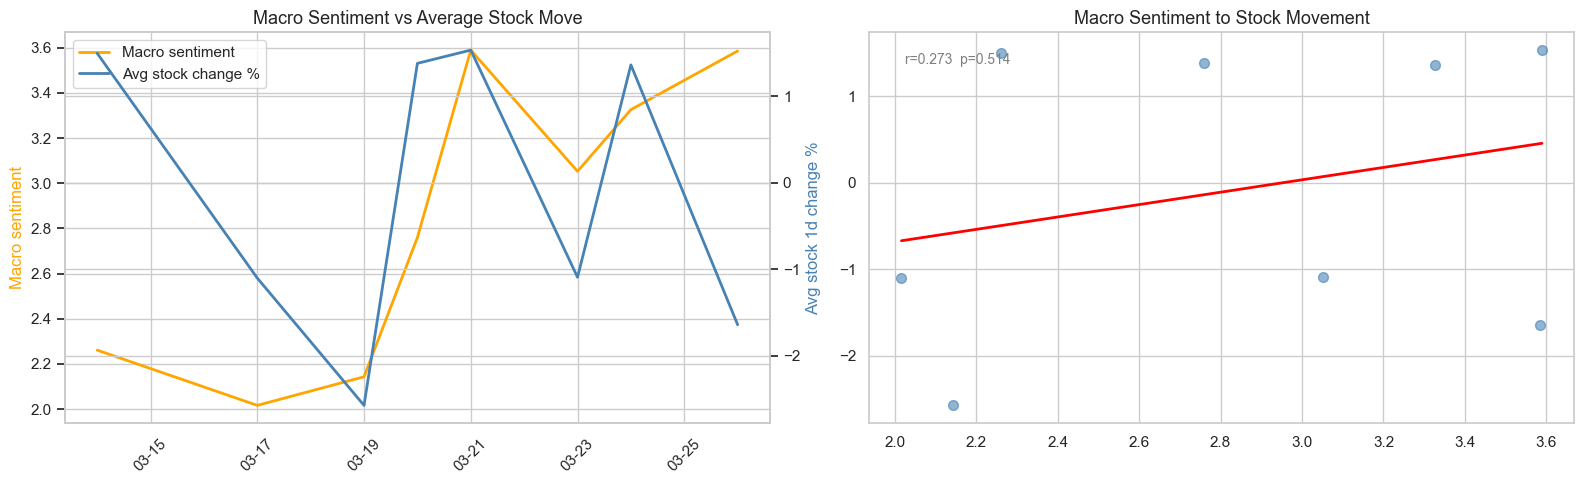


--- Daily Macro Sentiment vs Avg Stock Change ---


,date,macro_sentiment,avg_stock_change,macro_signal
0,2026-03-14,2.2609,1.4972,neutral
1,2026-03-17,2.0161,-1.1035,neutral
2,2026-03-19,2.1429,-2.5765,neutral
3,2026-03-20,2.7595,1.3800,neutral
4,2026-03-21,3.5895,1.5334,neutral
5,2026-03-23,3.0526,-1.0939,neutral
6,2026-03-24,3.3258,1.3624,neutral
7,2026-03-26,3.5856,-1.6435,neutral


  Saved: analysis\macro_vs_stocks.csv


In [23]:
macro_df    = df[df['category']=='sector/macro'].dropna(subset=['sentiment','date']).copy()
company_df2 = df[df['category']=='company'].dropna(subset=['change_1d','date']).copy()
if macro_df.empty or company_df2.empty:
    print('Not enough data yet')
else:
    daily_macro  = macro_df.groupby('date')['sentiment'].mean().reset_index()
    daily_macro.columns  = ['date','macro_sentiment']
    daily_stocks = company_df2.groupby('date')['change_1d'].mean().reset_index()
    daily_stocks.columns = ['date','avg_stock_change']
    merged = daily_macro.merge(daily_stocks, on='date')

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    ax2 = axes[0].twinx()
    axes[0].plot(merged['date'], merged['macro_sentiment'], color='orange', linewidth=2, label='Macro sentiment')
    ax2.plot(merged['date'], merged['avg_stock_change'], color='steelblue', linewidth=2, label='Avg stock change %')
    axes[0].set_ylabel('Macro sentiment', color='orange')
    ax2.set_ylabel('Avg stock 1d change %', color='steelblue')
    axes[0].set_title('Macro Sentiment vs Average Stock Move')
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)
    l1,lab1 = axes[0].get_legend_handles_labels()
    l2,lab2 = ax2.get_legend_handles_labels()
    axes[0].legend(l1+l2, lab1+lab2, loc='upper left')
    axes[1].scatter(merged['macro_sentiment'], merged['avg_stock_change'], alpha=0.6, s=50, color='steelblue')
    if len(merged) > 3:
        z = np.polyfit(merged['macro_sentiment'], merged['avg_stock_change'], 1)
        xs = np.linspace(merged['macro_sentiment'].min(), merged['macro_sentiment'].max(), 100)
        axes[1].plot(xs, np.poly1d(z)(xs), color='red', linewidth=2)
        r, p_val = stats.pearsonr(merged['macro_sentiment'], merged['avg_stock_change'])
        axes[1].annotate(f'r={r:.3f}  p={p_val:.3f}', xy=(0.05,0.92),
                         xycoords='axes fraction', fontsize=10,
                         color='red' if p_val<0.05 else 'grey')
    axes[1].set_title('Macro Sentiment to Stock Movement')
    plt.tight_layout(); plt.show()

    macro_table = merged.copy()
    macro_table['date'] = macro_table['date'].dt.strftime('%Y-%m-%d')
    macro_table = macro_table.round(4)
    macro_table['macro_signal'] = macro_table['macro_sentiment'].apply(
        lambda x: 'bullish' if x>=4 else ('bearish' if x<=2 else 'neutral'))
    print('\n--- Daily Macro Sentiment vs Avg Stock Change ---')
    display(macro_table)
    save_csv(macro_table.set_index('date'), 'macro_vs_stocks.csv')

## 8 — Sector Sentiment vs Constituent Stock Performance

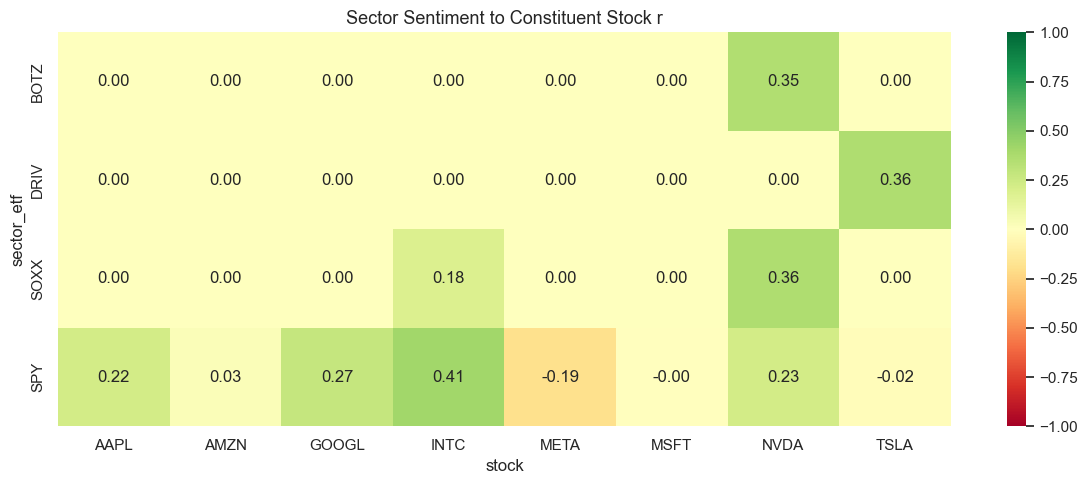


--- Sector Sentiment to Stock Correlation ---


,sector_etf,sector_name,stock,r,p,n_days,significant
11,SPY,S&P500,INTC,0.409,0.3621,7,No
3,DRIV,EV,TSLA,0.363,0.3765,8,No
0,SOXX,Semiconductor,NVDA,0.360,0.3810,8,No
2,BOTZ,AI/Robotics,NVDA,0.354,0.3892,8,No
10,SPY,S&P500,GOOGL,0.274,0.5520,7,No
4,SPY,S&P500,NVDA,0.225,0.6276,7,No
5,SPY,S&P500,AAPL,0.220,0.6351,7,No
1,SOXX,Semiconductor,INTC,0.183,0.6644,8,No
9,SPY,S&P500,AMZN,0.030,0.9493,7,No
6,SPY,S&P500,MSFT,-0.003,0.9955,6,No


  Saved: analysis\correlations_sector_vs_stocks.csv


In [24]:
SECTOR_STOCKS = {
    'QQQ':  ['NVDA','AAPL','MSFT','META','TSLA','AMZN','GOOGL','INTC','AMD'],
    'SOXX': ['NVDA','INTC','AMD'],
    'BOTZ': ['NVDA'],
    'DRIV': ['TSLA'],
    'SPY':  ['NVDA','AAPL','MSFT','META','TSLA','AMZN','GOOGL','INTC','AMD'],
}
sector_df   = df[df['category']=='sector/macro'].dropna(subset=['sentiment','date']).copy()
company_df3 = df[df['category']=='company'].dropna(subset=['change_1d','date']).copy()
results = []
for sector_ticker, stock_tickers in SECTOR_STOCKS.items():
    sector_news = sector_df[sector_df['ticker']==sector_ticker]
    if sector_news.empty: continue
    daily_sector = sector_news.groupby('date')['sentiment'].mean()
    for stock in stock_tickers:
        stock_prices = company_df3[company_df3['ticker']==stock]
        if stock_prices.empty: continue
        daily_stock = stock_prices.groupby('date')['change_1d'].mean()
        merged = daily_sector.rename('sector_sent').reset_index() \
            .merge(daily_stock.rename('stock_chg').reset_index(), on='date')
        if len(merged) < 5: continue
        r, p_val = stats.pearsonr(merged['sector_sent'], merged['stock_chg'])
        results.append({'sector_etf': sector_ticker,
                        'sector_name': ETF_LABELS.get(sector_ticker, sector_ticker),
                        'stock': stock, 'r': round(r,3), 'p': round(p_val,4),
                        'n_days': len(merged),
                        'significant': 'Yes' if p_val<0.05 else 'No'})
if results:
    res_df  = pd.DataFrame(results)
    pivot_r = res_df.pivot_table(index='sector_etf', columns='stock', values='r', fill_value=0)
    plt.figure(figsize=(12, 5))
    sns.heatmap(pivot_r, annot=True, fmt='.2f', cmap='RdYlGn', center=0, vmin=-1, vmax=1)
    plt.title('Sector Sentiment to Constituent Stock r')
    plt.tight_layout(); plt.show()
    print('\n--- Sector Sentiment to Stock Correlation ---')
    display(res_df.sort_values('r', ascending=False))
    save_csv(res_df.set_index(['sector_etf','stock']), 'correlations_sector_vs_stocks.csv')
else:
    print('Not enough overlapping dates yet')

## 9 — Dataset Readiness Summary

In [25]:
labeled = df.dropna(subset=['sentiment','bucket_1d'])

ticker_ready = labeled.groupby(['ticker','category']).agg(
    total_articles  = ('url',       'count'),
    unique_days     = ('date',      'nunique'),
    avg_sentiment   = ('sentiment', 'mean'),
    flat_pct        = ('bucket_1d', lambda x: round((x=='flat').mean()*100,1)),
    strong_down_pct = ('bucket_1d', lambda x: round((x=='strong_down').mean()*100,1)),
    strong_up_pct   = ('bucket_1d', lambda x: round((x=='strong_up').mean()*100,1)),
).round(2).reset_index()
ticker_ready['imbalance_flag'] = ticker_ready['flat_pct'].apply(
    lambda x: 'HIGH FLAT' if x>70 else 'OK')
ticker_ready['readiness'] = ticker_ready['total_articles'].apply(
    lambda x: 'LOW <50' if x<50 else ('MED 50-200' if x<200 else 'READY 200+'))

print('='*60)
print('DATASET READINESS SUMMARY')
print('='*60)
print(f'Total articles:    {len(df):>6,}')
print(f'With sentiment:    {df["sentiment"].notna().sum():>6,}')
print(f'With price bucket: {df["bucket_1d"].notna().sum():>6,}')
print(f'Fully labeled:     {len(labeled):>6,}')
print()
display(ticker_ready)
save_csv(ticker_ready.set_index('ticker'), 'dataset_readiness.csv')

total = len(labeled)
print()
if total < 500:
    print(f'  {total} examples — keep collecting (target 500+)')
elif total < 2000:
    print(f'  {total} examples — borderline, proceed with caution')
else:
    print(f'  {total} examples — ready to fine-tune!')

print(f'\nCSVs in {ANALYSIS_DIR}/')
for f in sorted(os.listdir(ANALYSIS_DIR)):
    if f.endswith('.csv'):
        print(f'  {f}')

DATASET READINESS SUMMARY
Total articles:     2,128
With sentiment:     1,721
With price bucket:  1,393
Fully labeled:      1,393



,ticker,category,total_articles,unique_days,avg_sentiment,flat_pct,strong_down_pct,strong_up_pct,imbalance_flag,readiness
0,AAPL,company,104,8,3.07,100.0,0.0,0.0,HIGH FLAT,MED 50-200
1,AMZN,company,69,8,3.13,36.2,0.0,0.0,OK,MED 50-200
2,BOTZ,sector/macro,33,8,2.58,87.9,0.0,0.0,HIGH FLAT,LOW <50
3,DRIV,sector/macro,35,8,2.86,68.6,0.0,0.0,OK,LOW <50
4,GOOGL,company,100,8,2.76,89.0,0.0,0.0,HIGH FLAT,MED 50-200
5,INTC,company,62,8,3.08,61.3,14.5,9.7,OK,MED 50-200
6,META,company,134,8,2.60,53.0,0.0,0.0,OK,MED 50-200
7,MSFT,company,70,6,3.20,91.4,0.0,0.0,HIGH FLAT,MED 50-200
8,NVDA,company,216,8,3.25,86.1,0.0,0.0,HIGH FLAT,READY 200+
9,SKYY,sector/macro,52,8,3.52,46.2,0.0,0.0,OK,MED 50-200


  Saved: analysis\dataset_readiness.csv

  1393 examples — borderline, proceed with caution

CSVs in analysis/
  correlations_sector_vs_stocks.csv
  correlations_stock_vs_benchmark.csv
  dataset_readiness.csv
  dist_articles_per_day.csv
  dist_articles_per_ticker.csv
  dist_magnitude.csv
  dist_price_buckets.csv
  dist_price_buckets_per_ticker.csv
  dist_sentiment.csv
  dist_sentiment_per_ticker.csv
  dist_ticker_day_heatmap.csv
  edge_cases.csv
  macro_vs_stocks.csv
  mismatch_confusion_matrix.csv
  mismatch_rate_per_ticker.csv
